In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline 
import seaborn as sns

In [2]:
# import CSV file
df = pd.read_excel("D:\Jupyter Notebook File\Diwali Sales Data.xlsx")

In [3]:
df.shape

(11251, 13)

In [4]:
df.head(10)

,User_ID,Cust_name,Product_ID,Gender,Age_Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.00
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.00
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.00
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.00
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.00
5,1000588,Joni,P00057942,M,26-35,28,1,Himachal Pradesh,Northern,Food Processing,Auto,1,23877.00
6,1001132,Balk,P00018042,F,18-25,25,1,Uttar Pradesh,Central,Lawyer,Auto,4,23841.00
7,1002092,Shivangi,P00273442,F,55+,61,0,Maharashtra,Western,IT Sector,Auto,1,NaN
8,1003224,Kushal,P00205642,M,26-35,35,0,Uttar Pradesh,Central,Govt,Auto,2,23809.00
9,1003650,Ginny,P00031142,F,26-35,26,1,Andhra Pradesh,Southern,Media,Auto,4,23799.99


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  object 
 2   Product_ID        11251 non-null  object 
 3   Gender            11251 non-null  object 
 4   Age_Group         11251 non-null  object 
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  object 
 8   Zone              11251 non-null  object 
 9   Occupation        11251 non-null  object 
 10  Product_Category  11251 non-null  object 
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
dtypes: float64(1), int64(4), object(8)
memory usage: 1.1+ MB


In [6]:
# check for Null Value
pd.isnull(df).sum()

User_ID              0
Cust_name            0
Product_ID           0
Gender               0
Age_Group            0
Age                  0
Marital_Status       0
State                0
Zone                 0
Occupation           0
Product_Category     0
Orders               0
Amount              12
dtype: int64

In [7]:
# drop Null Values
df.dropna(inplace= True)

In [8]:
pd.isnull(df).sum()

User_ID             0
Cust_name           0
Product_ID          0
Gender              0
Age_Group           0
Age                 0
Marital_Status      0
State               0
Zone                0
Occupation          0
Product_Category    0
Orders              0
Amount              0
dtype: int64

In [9]:
# change data type 
df['Amount'] = df['Amount'].astype('int')

In [10]:
df['Amount'].dtypes

dtype('int64')

In [11]:
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age_Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount'],
      dtype='object')

In [12]:
# df.describe give the description of data in d dataframe ( i.e count mean std etc)

df.describe()

,User_ID,Age,Marital_Status,Orders,Amount
count,1.123900e+04,11239.000000,11239.000000,11239.000000,11239.000000
mean,1.003004e+06,35.410357,0.420055,2.489634,9453.610553
std,1.716039e+03,12.753866,0.493589,1.114967,5222.355168
min,1.000001e+06,12.000000,0.000000,1.000000,188.000000
25%,1.001492e+06,27.000000,0.000000,2.000000,5443.000000
50%,1.003064e+06,33.000000,0.000000,2.000000,8109.000000
75%,1.004426e+06,43.000000,1.000000,3.000000,12675.000000
max,1.006040e+06,92.000000,1.000000,4.000000,23952.000000


In [13]:
# use describe() for specific columns
df[['Age', 'Orders', 'Amount']].describe()

,Age,Orders,Amount
count,11239.000000,11239.000000,11239.000000
mean,35.410357,2.489634,9453.610553
std,12.753866,1.114967,5222.355168
min,12.000000,1.000000,188.000000
25%,27.000000,2.000000,5443.000000
50%,33.000000,2.000000,8109.000000
75%,43.000000,3.000000,12675.000000
max,92.000000,4.000000,23952.000000


Exploratory Data Analysis 

Gender

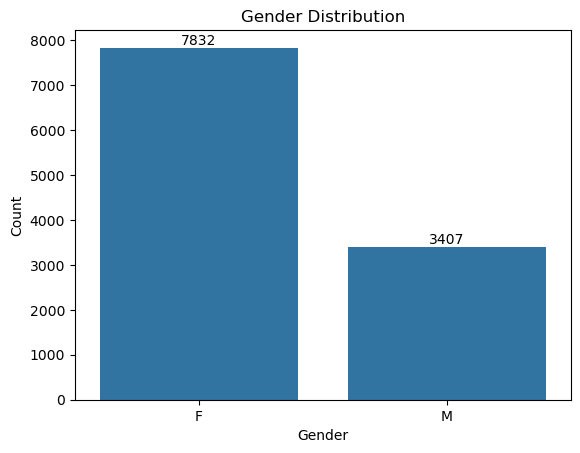

In [14]:
# Create countplot
ax = sns.countplot(x='Gender', data=df)

# Add labels on top of bars
for bars in ax.containers:
    ax.bar_label(bars)

# Add axis labels and title
plt.xlabel("Gender")
plt.ylabel("Count")
plt.title("Gender Distribution")

# Show plot
plt.show()

This Graph shows that during the Diwali Festival women are more excited to do marketing and they will try to buy every new items
which were need for Diwali this Graph shows that the total survey of 11251 buyers, out of these buyers 7832 are women and just only 3407 
men 

In [15]:
df.groupby(['Gender'],as_index=False)['Amount'].sum().sort_values(by='Amount',ascending=False)

,Gender,Amount
0,F,74335853
1,M,31913276


Total Amount spend by Female during Diwali Festival is more than 7 crore rupees while male just spend only 3.19 crore 

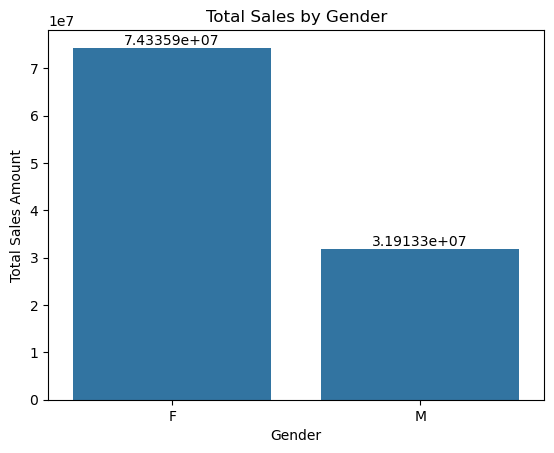

In [16]:
# Grouped data
Sales_Gender = df.groupby(['Gender'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)

# Barplot
ax = sns.barplot(x='Gender', y='Amount', data=Sales_Gender)

# Add labels on top of bars
for bars in ax.containers:
    ax.bar_label(bars)

# Add axis labels and title
plt.xlabel("Gender")
plt.ylabel("Total Sales Amount")
plt.title("Total Sales by Gender")

# Show plot
plt.show()


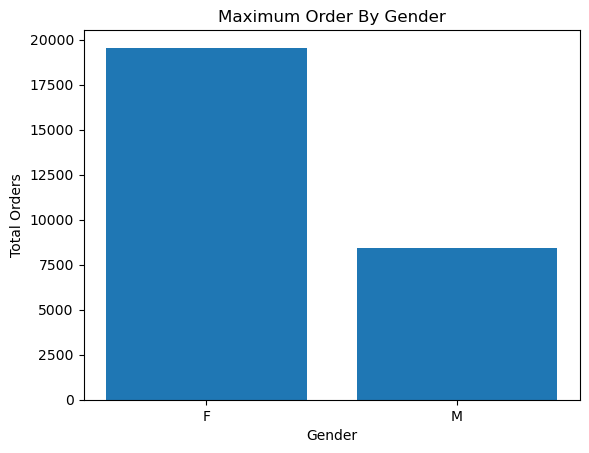

In [17]:
# # group data 
Buy_orders = df.groupby(['Gender'], as_index=False)['Orders'].sum().sort_values(by='Orders', ascending=False)

# create bar plot
plt.bar(Buy_orders['Gender'], Buy_orders['Orders'])

# add axis labels and title
plt.xlabel("Gender")
plt.ylabel("Total Orders")
plt.title("Maximum Order By Gender")

plt.show()     

Most of the Order During Diwali Festival time are done by the women, 19548 orders are done by women while only 8433 orders
are done by men 

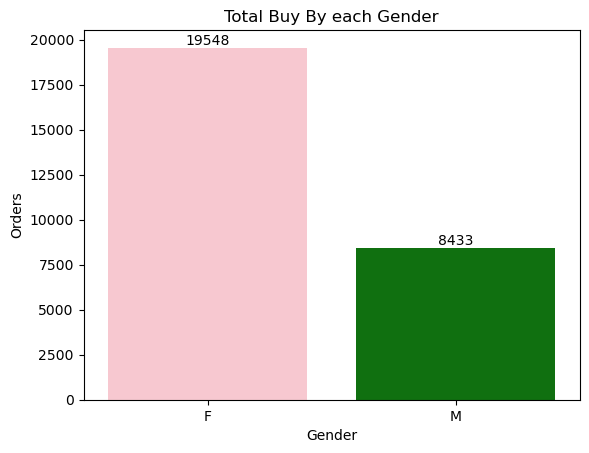

In [18]:
# grouped data 
Buy_order = df.groupby(['Gender'],as_index=False)['Orders'].sum().sort_values(by='Orders',ascending=False)

# Barplot with custom colours 
dx = sns.barplot(
    x='Gender',
    y= 'Orders',
    data= Buy_orders,
    hue='Gender',
    palette={'M':'Green', 'F':'pink'},
    legend=False
)

# add label on the top of the bar
for bars in dx.containers:
    dx.bar_label(bars)
    
# add axis label and title
plt.xlabel("Gender")
plt.ylabel("Orders")
plt.title("Total Buy By each Gender")

plt.show()

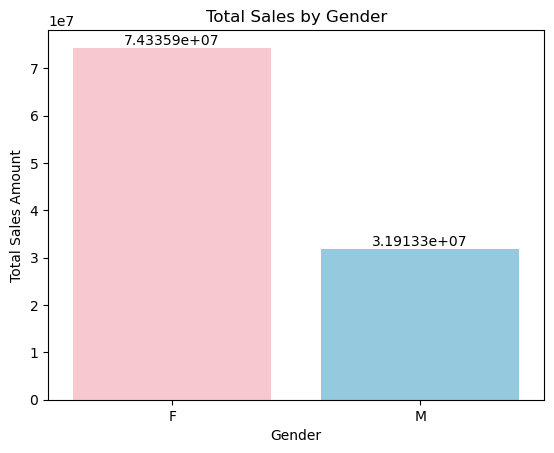

In [19]:
# Grouped data
Sales_Gender = df.groupby(['Gender'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)

# Barplot with custom colors (matching your actual values in Gender column)
ax = sns.barplot(
    x='Gender',
    y='Amount',
    data=Sales_Gender,
    hue='Gender',                  # assign hue to avoid the FutureWarning
    palette={'M': 'skyblue', 'F': 'pink'},  
    legend=False                   # remove duplicate legend
)

# Add labels on top of bars
for bars in ax.containers:
    ax.bar_label(bars)

# Add axis labels and title
plt.xlabel("Gender")
plt.ylabel("Total Sales Amount")
plt.title("Total Sales by Gender")

plt.show()


Most of the buyers are female and they have more purchasing power parity

Age

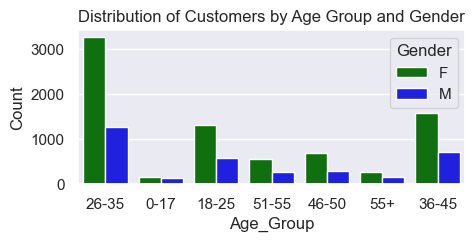

In [37]:
ax = sns.countplot(data=df, x='Age_Group', hue='Gender',palette= {'M':'Blue', 'F':'Green'})

# Add labels
plt.xlabel("Age_Group")
plt.ylabel("Count")
plt.title("Distribution of Customers by Age Group and Gender")

plt.show()

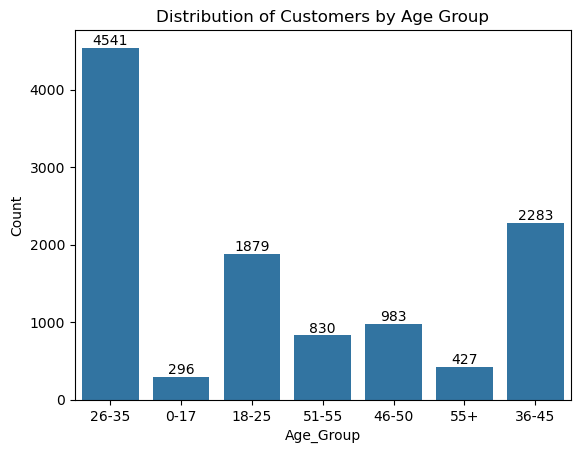

In [21]:
ax = sns.countplot(data=df, x='Age_Group')

# Add labels
plt.xlabel("Age_Group")
plt.ylabel("Count")
plt.title("Distribution of Customers by Age Group")

# Add labels on top of bars
for bars in ax.containers:
    ax.bar_label(bars)

plt.show()

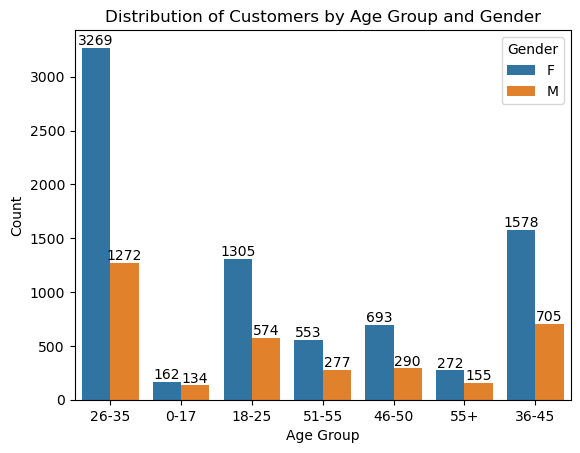

In [22]:
ax = sns.countplot(data=df, x='Age_Group', hue='Gender')

# Add labels
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.title("Distribution of Customers by Age Group and Gender")

# Add labels on top of bars
for bars in ax.containers:
    ax.bar_label(bars)

plt.show()

From above Graphs we can see that most of the buyers are from the age group between 26-35 years Females

States Related Analysis

C:\Users\MD BILAL ANSARI\AppData\Local\Temp\ipykernel_10212\2587737879.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=Sales_State, x='State', y='Orders', palette="viridis")


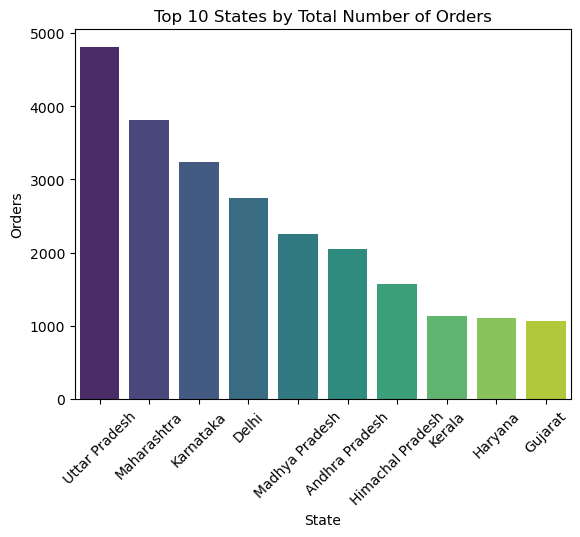

In [23]:
# Group by state and get top 10 states by total orders
Sales_State = (
    df.groupby('State', as_index=False)['Orders']
      .sum()
      .sort_values(by='Orders', ascending=False)
      .head(10)
)

# Set figure size properly (typo in your code: 'Figure,figsize' → should be 'figure.figsize')
#sns.set(rc={'figure.figsize': (15,5)})

# Create barplot
sns.barplot(data=Sales_State, x='State', y='Orders', palette="viridis")

# Add title and rotate x-axis labels for readability
plt.title("Top 10 States by Total Number of Orders")
plt.xticks(rotation=45)
plt.show()


C:\Users\MD BILAL ANSARI\AppData\Local\Temp\ipykernel_10212\2969492696.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=Sales_State, x='State', y='Amount', palette="viridis")


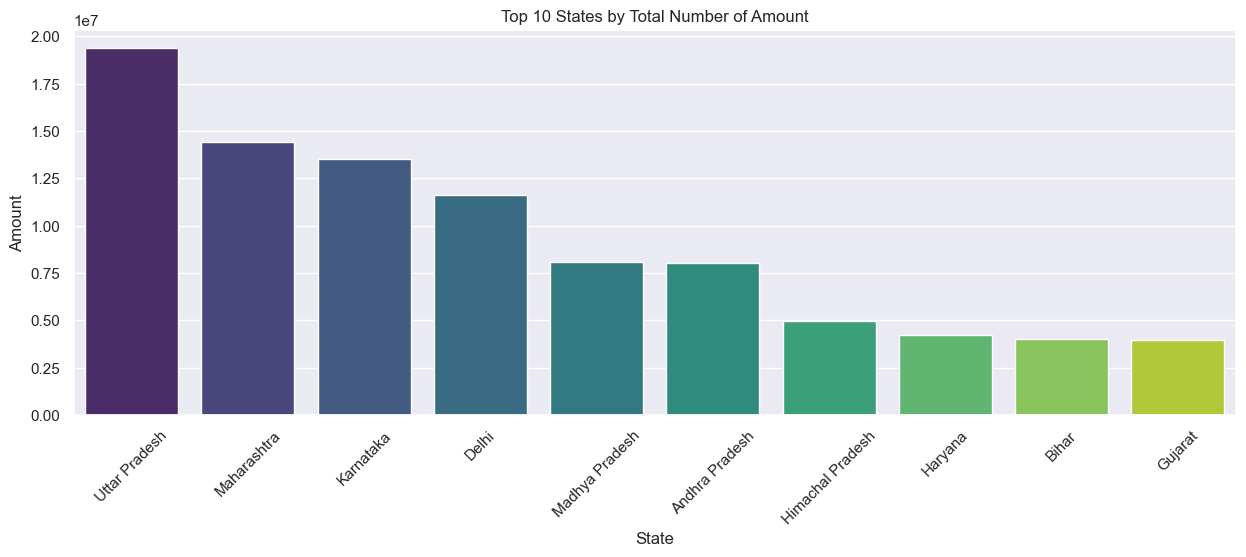

In [24]:
# total amount/sales from top 10 states

Sales_State = (
    df.groupby('State', as_index=False)['Amount']
      .sum()
      .sort_values(by='Amount', ascending=False)
      .head(10)
)

# Set figure size properly (typo in your code: 'Figure,figsize' → should be 'figure.figsize')
sns.set(rc={'figure.figsize': (15,5)})

# Create barplot
sns.barplot(data=Sales_State, x='State', y='Amount', palette="viridis")

# Add title and rotate x-axis labels for readability
plt.title("Top 10 States by Total Number of Amount")
plt.xticks(rotation=45)
plt.show()


from both above graphs we have seem that most of the sale and order are from Uttar Pradesh and Maharashtra 

Marital Status Related Analysis

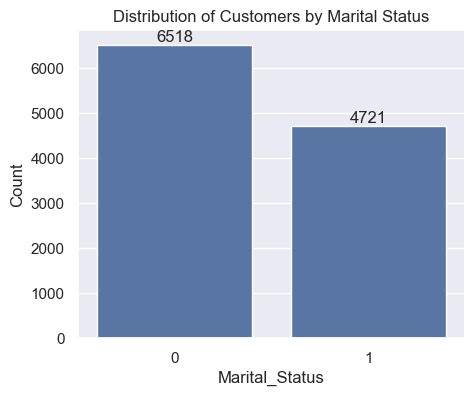

In [34]:
ax = sns.countplot(data=df, x='Marital_Status')

# Add labels
plt.xlabel("Marital_Status")
plt.ylabel("Count")
plt.title("Distribution of Customers by Marital Status")

# Set figure size properly (typo in your code: 'Figure,figsize' → should be 'figure.figsize')
sns.set(rc={'figure.figsize': (5,2)})

# Add labels on top of bars
for bars in ax.containers:
    ax.bar_label(bars)

plt.show()

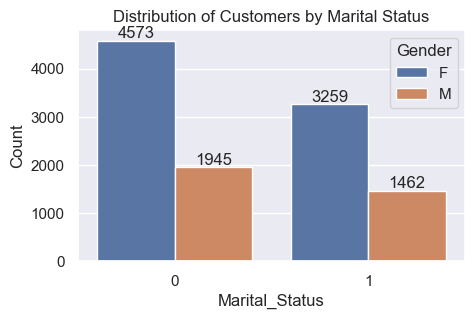

In [26]:
ax = sns.countplot(data=df, x='Marital_Status', hue='Gender')

# Add labels
plt.xlabel("Marital_Status")
plt.ylabel("Count")
plt.title("Distribution of Customers by Marital Status")

# Add labels on top of bars
for bars in ax.containers:
    ax.bar_label(bars)

plt.show()

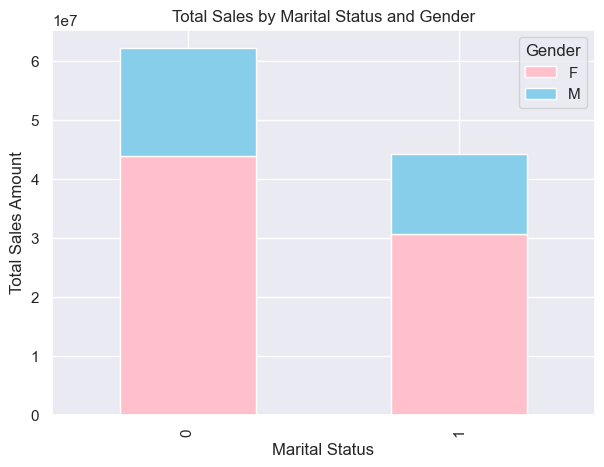

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

# Grouped data
Sales_State = (
    df.groupby(['Marital_Status', 'Gender'], as_index=False)['Amount']
      .sum()
      .sort_values(by='Amount', ascending=False)
)

# Pivot the table for stacked bar chart
pivot_data = Sales_State.pivot(index='Marital_Status', columns='Gender', values='Amount')

# Plot stacked bar chart
pivot_data.plot(kind='bar', stacked=True, color={'M': 'skyblue', 'F': 'pink'}, figsize=(7,5))

plt.xlabel("Marital Status")
plt.ylabel("Total Sales Amount")
plt.title("Total Sales by Marital Status and Gender")
plt.legend(title="Gender")
plt.show()

From the above graphs we have seen that most of the buyers are Married women 

Occupation related Analysis

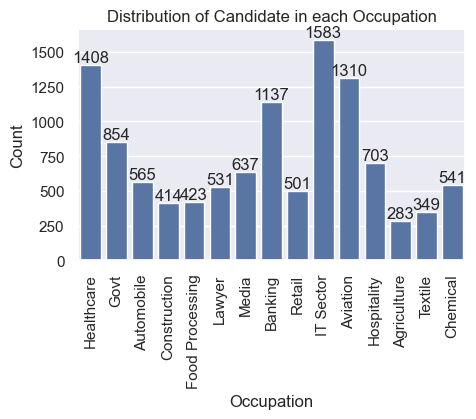

In [28]:
ax = sns.countplot(data=df, x='Occupation')

# Add labels
plt.xlabel("Occupation")
plt.ylabel("Count")
plt.title("Distribution of Candidate in each Occupation")
plt.xticks(rotation=90)

# Set figure size properly (typo in your code: 'Figure,figsize' → should be 'figure.figsize')
sns.set(rc={'figure.figsize': (10,4)})

# Add labels on top of bars
for bars in ax.containers:
    ax.bar_label(bars)

plt.show()

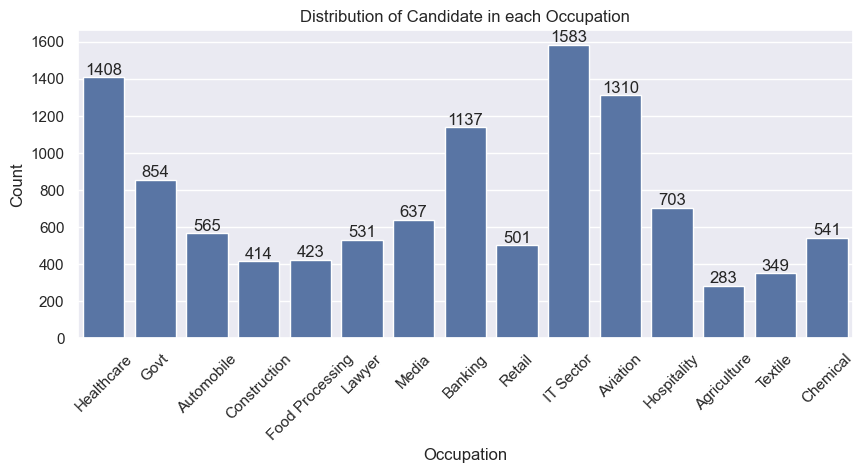

In [29]:
ax = sns.countplot(data=df, x='Occupation')

# Add labels
plt.xlabel("Occupation")
plt.ylabel("Count")
plt.title("Distribution of Candidate in each Occupation")
plt.xticks(rotation=45)

# Set figure size properly (typo in your code: 'Figure,figsize' → should be 'figure.figsize')
sns.set(rc={'figure.figsize': (10,4)})

# Add labels on top of bars
for bars in ax.containers:
    ax.bar_label(bars)

plt.show()

Most of the workers who works on IT Sector, Healthcar and Aviation has spend more during Diwali Festival and employees
who spend less during Diwali Festival works on agriculture, Textile and construction 

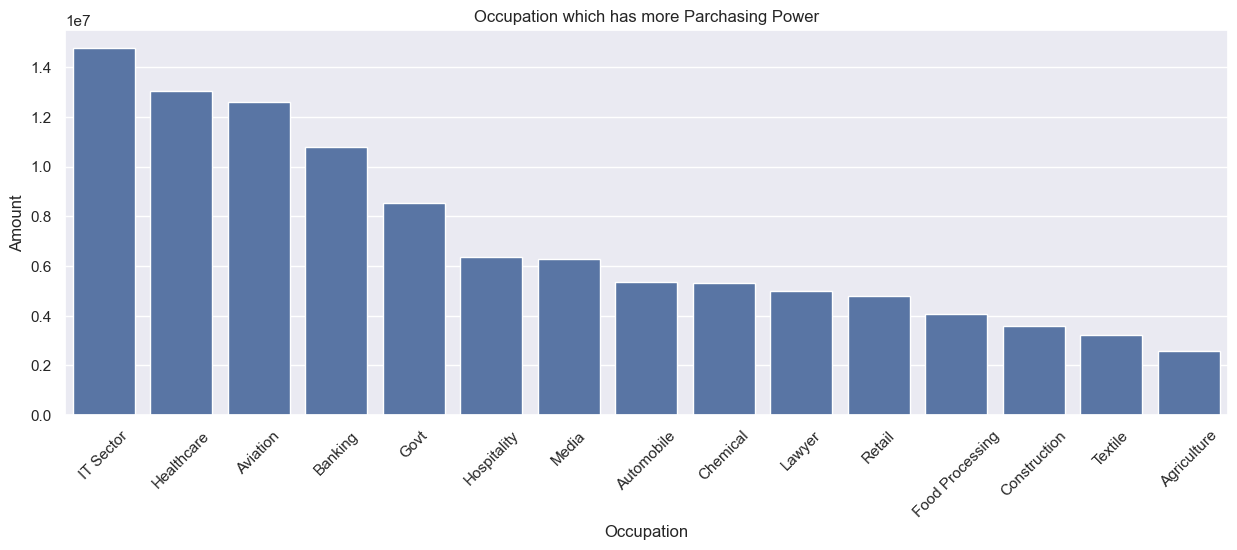

In [30]:
Sales_State = (
    df.groupby('Occupation', as_index=False)['Amount']
      .sum()
      .sort_values(by='Amount', ascending=False)
)

# Set figure size properly (typo in your code: 'Figure,figsize' → should be 'figure.figsize')
sns.set(rc={'figure.figsize': (15,5)})

# Create barplot
sns.barplot(data=Sales_State, x='Occupation', y='Amount')

# Add title and rotate x-axis labels for readability
plt.title("Occupation which has more Parchasing Power")
plt.xticks(rotation=45)
plt.show()


From above both graph we can see that most of the buyers are working in IT Sector, Health Care and Aviation

Product Category related Analysis

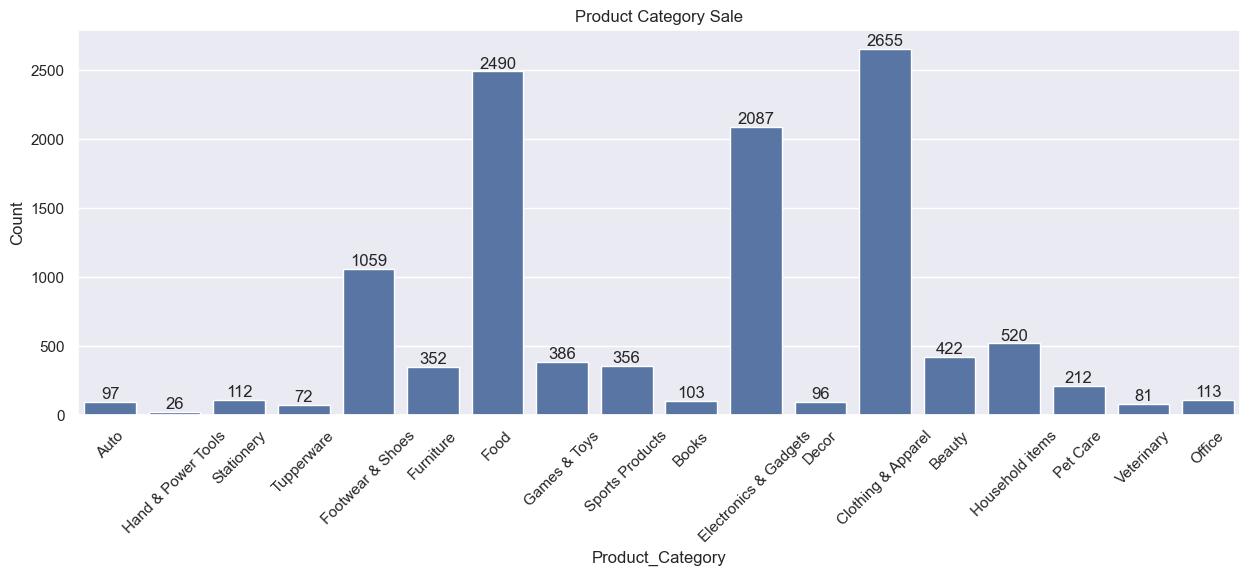

In [31]:
ax = sns.countplot(data=df, x='Product_Category')

# Add labels
plt.xlabel("Product_Category")
plt.ylabel("Count")
plt.title("Product Category Sale")
plt.xticks(rotation=45)

# Add labels on top of bars
for bars in ax.containers:
    ax.bar_label(bars)

plt.show()


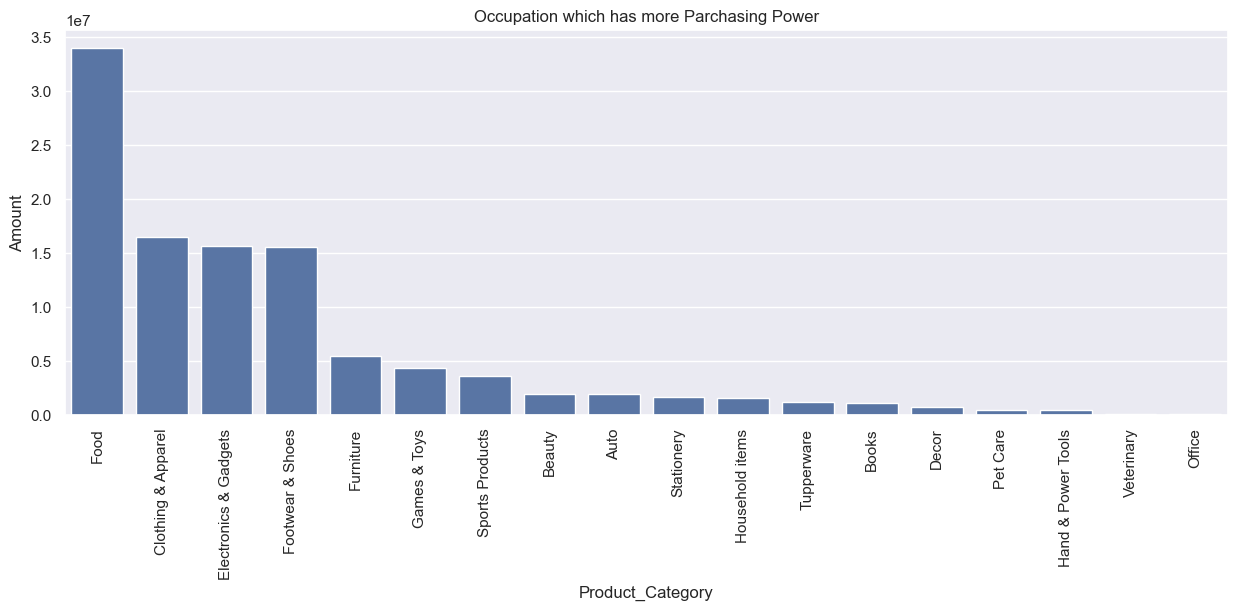

In [38]:
Sales_State = (
    df.groupby('Product_Category', as_index=False)['Amount']
      .sum()
      .sort_values(by='Amount', ascending=False)
)

# Set figure size properly (typo in your code: 'Figure,figsize' → should be 'figure.figsize')
sns.set(rc={'figure.figsize': (15,5)})

# Create barplot
sns.barplot(data=Sales_State, x='Product_Category', y='Amount')

# Add title and rotate x-axis labels for readability
plt.title("Occupation which has more Parchasing Power")
plt.xticks(rotation=90)
plt.show()

From Above Graphs we conclude that Most of the money was invested in Food but most numbers or orders are clothing